# Phase 2 — Static Fuzzy Baseline

Dự án: **An Evolving Fuzzy Reasoning System for Sensor Stream Anomaly Detection under Concept Drift**

## Mục tiêu Phase 2:
Xây dựng hệ suy luận mờ tĩnh (**Static Fuzzy Baseline**) làm chuẩn đối chứng trước khi tích hợp các cơ chế tự tiến hóa (evolving) và phát hiện trôi dạt khái niệm (concept drift detection).

Các bước thực hiện trong Phase 2:
- **2.1**: Thiết kế FIS (Mamdani, Anomaly Score $\in [0, 1]$, centroid) - *Đã chốt ở docs/phase-02.1-fuzzy-reasoning-target.md*
- **2.2**: Phân tích phân phối Train (Train Distribution Analysis) $\rightarrow$ Xác định các mốc Membership Functions (MF)
- **2.3**: Xây dựng Membership Functions (5 inputs + 1 output)
- **2.4**: Thiết kế Fuzzy Rule Base (~10–20 rules)
- **2.5**: Xây dựng Mamdani FIS hoàn chỉnh
- **2.6**: Kiểm thử FIS (Test mẫu & trực quan hóa suy luận)
- **2.7**: Chốt Static Baseline & đóng băng sẵn sàng sang Phase 3

---
## Phase 2.2 — Phân tích phân phối Train để xác định Membership Functions

Nguyên tắc quan trọng:
- Toàn bộ tri thức và các mốc hàm thuộc tính (MF) được thiết kế **dựa trên 6.000 mẫu Train** (UDI: 1 $\rightarrow$ 6.000).
- Tuyệt đối không sử dụng nhãn `Machine failure` hoặc dữ liệu Validation/Test để dò/tối ưu MF ở bước này.


### Phase 2.2.1 — Chuẩn bị dữ liệu Train và Thống kê mô tả

In [1]:
# Phase 2.2.1 — Prepare training data
from pathlib import Path
import pandas as pd
import numpy as np

# Load dữ liệu (hỗ trợ cả khi chạy từ notebook dir hoặc project root)
data_path = Path("../data/ai4i2020.csv") if Path("../data/ai4i2020.csv").exists() else Path("data/ai4i2020.csv")
df = pd.read_csv(data_path)

sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

train_df = df.iloc[:6000].copy()

print("Train shape:", train_df.shape)
print("UDI range:", train_df["UDI"].min(), "→", train_df["UDI"].max())

display(train_df[sensor_cols].describe().T)


Train shape: (6000, 14)
UDI range: 1 → 6000


,count,mean,std,min,25%,50%,75%,max
Air temperature [K],6000.0,300.321550,2.283496,295.3,298.300,300.4,302.3,304.5
Process temperature [K],6000.0,309.922000,1.665028,305.7,308.600,309.7,311.1,313.8
Rotational speed [rpm],6000.0,1539.999667,182.909386,1168.0,1422.000,1504.0,1612.0,2886.0
Torque [Nm],6000.0,39.954950,9.977035,3.8,33.275,40.0,46.8,76.2
Tool wear [min],6000.0,108.960000,63.976469,0.0,54.000,109.0,164.0,253.0


### Phase 2.2.2 — Phân tích phân phối chi tiết qua các phân vị (Quantiles)

In [2]:
# Phase 2.2.2 — Detailed distribution statistics

quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

distribution_stats = train_df[sensor_cols].quantile(quantiles).T

display(distribution_stats)


,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
Air temperature [K],295.600,296.8,297.40,298.300,300.4,302.3,303.4,303.7,304.20
Process temperature [K],306.200,307.5,307.80,308.600,309.7,311.1,312.3,312.8,313.40
Rotational speed [rpm],1278.000,1331.0,1363.90,1422.000,1504.0,1612.0,1748.0,1877.0,2206.05
Torque [Nm],16.499,23.3,27.19,33.275,40.0,46.8,52.5,55.8,62.80
Tool wear [min],0.000,10.0,20.00,54.000,109.0,164.0,197.0,208.0,225.00


### Phase 2.2.3 — Trực quan hóa phân phối 5 biến cảm biến trên Train Set

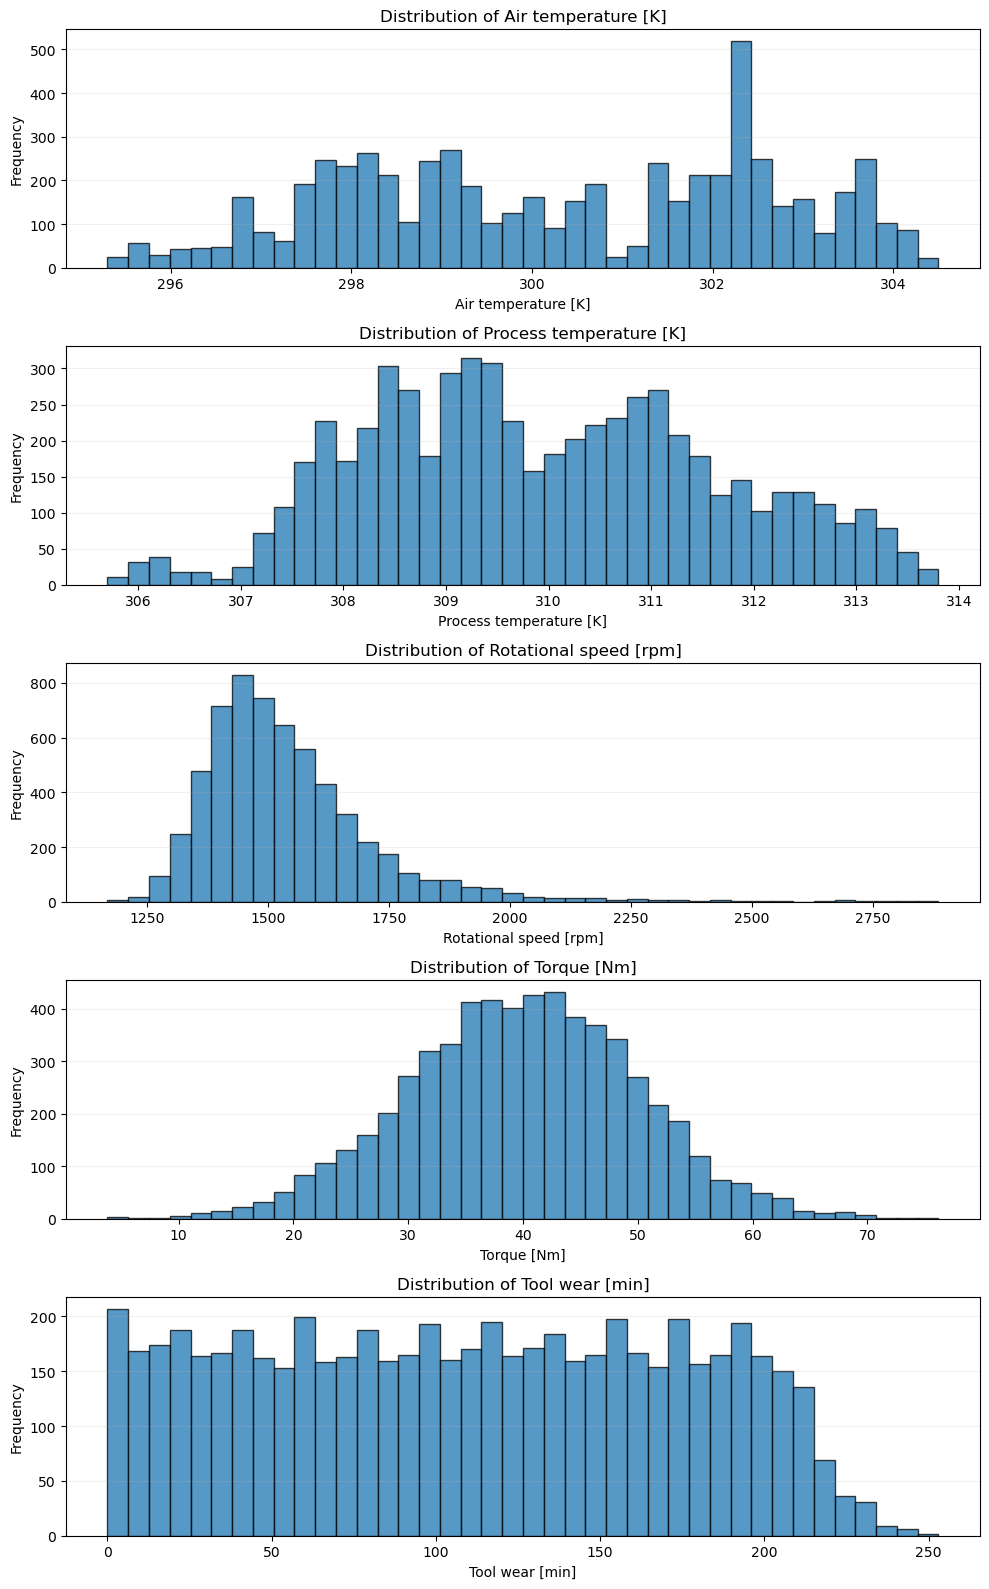

In [3]:
# Phase 2.2.3 — Visualize sensor distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(10, 16))

for ax, col in zip(axes, sensor_cols):
    ax.hist(
        train_df[col],
        bins=40,
        edgecolor="black",
        alpha=0.75
    )
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


---
## Phase 2.3 — Xây dựng Membership Functions (5 inputs + 1 output)

### Phase 2.3.1 — Kiểm tra thư viện scikit-fuzzy

In [4]:
# Phase 2.3.1 — Check scikit-fuzzy
import skfuzzy as fuzz

print("scikit-fuzzy:", fuzz.__version__)

scikit-fuzzy: 0.5.0


### Phase 2.3.2 — Khởi tạo miền giá trị (Fuzzy Universes) cho 5 inputs và 1 output

In [5]:
# Phase 2.3.2 — Define fuzzy universes

import numpy as np

universes = {
    "air_temp": np.linspace(295.3, 304.5, 1000),
    "process_temp": np.linspace(305.7, 313.8, 1000),
    "rpm": np.linspace(1168, 2886, 1000),
    "torque": np.linspace(3.8, 76.2, 1000),
    "tool_wear": np.linspace(0, 253, 1000),
    "anomaly": np.linspace(0, 1, 1000),
}

for name, universe in universes.items():
    print(
        f"{name:15s}: "
        f"min={universe.min():.2f}, "
        f"max={universe.max():.2f}, "
        f"points={len(universe)}"
    )

air_temp       : min=295.30, max=304.50, points=1000
process_temp   : min=305.70, max=313.80, points=1000
rpm            : min=1168.00, max=2886.00, points=1000
torque         : min=3.80, max=76.20, points=1000
tool_wear      : min=0.00, max=253.00, points=1000
anomaly        : min=0.00, max=1.00, points=1000


### Phase 2.3.3 — Xây dựng và Trực quan hóa Membership Functions cho Air Temperature

In [6]:
# Phase 2.3.3 — Air Temperature Membership Functions

air_temp = universes["air_temp"]

air_low = fuzz.trapmf(
    air_temp,
    [295.3, 295.3, 298.0, 300.4]
)

air_medium = fuzz.trimf(
    air_temp,
    [298.0, 300.4, 302.5]
)

air_high = fuzz.trapmf(
    air_temp,
    [300.4, 302.5, 304.5, 304.5]
)

print("Air Temperature MFs created.")
print("LOW    :", air_low.shape)
print("MEDIUM :", air_medium.shape)
print("HIGH   :", air_high.shape)

Air Temperature MFs created.
LOW    : (1000,)
MEDIUM : (1000,)
HIGH   : (1000,)


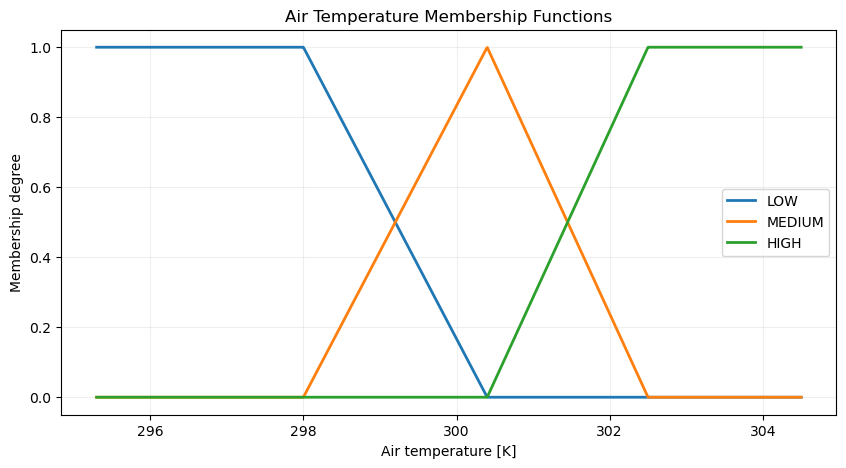

In [7]:
# Visualize Air Temperature Membership Functions

plt.figure(figsize=(10, 5))

plt.plot(air_temp, air_low, label="LOW", linewidth=2)
plt.plot(air_temp, air_medium, label="MEDIUM", linewidth=2)
plt.plot(air_temp, air_high, label="HIGH", linewidth=2)

plt.title("Air Temperature Membership Functions")
plt.xlabel("Air temperature [K]")
plt.ylabel("Membership degree")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

### Phase 2.3.4 — Kiểm tra tính đầy đủ và liên tục của phân hoạch mờ Air Temperature trên toàn bộ Universe

In [8]:
# Phase 2.3.4 — Verify Air Temperature fuzzy partition

air_membership_sum = air_low + air_medium + air_high

print("Minimum sum of memberships:", air_membership_sum.min())
print("Maximum sum of memberships:", air_membership_sum.max())

print(
    "All points approximately equal to 1:",
    np.allclose(air_membership_sum, 1.0, atol=1e-6)
)

print(
    "Maximum deviation from 1:",
    np.max(np.abs(air_membership_sum - 1.0))
)

Minimum sum of memberships: 1.0
Maximum sum of memberships: 1.0
All points approximately equal to 1: True
Maximum deviation from 1: 0.0


### Phase 2.3.5 — Xây dựng, Trực quan hóa và Kiểm tra Membership Functions cho Process Temperature

In [9]:
# Phase 2.3.5 — Process Temperature Membership Functions

process_temp = universes["process_temp"]

process_low = fuzz.trapmf(
    process_temp,
    [305.7, 305.7, 308.0, 309.7]
)

process_medium = fuzz.trimf(
    process_temp,
    [308.0, 309.7, 311.5]
)

process_high = fuzz.trapmf(
    process_temp,
    [309.7, 311.5, 313.8, 313.8]
)

print("Process Temperature MFs created.")
print("LOW    :", process_low.shape)
print("MEDIUM :", process_medium.shape)
print("HIGH   :", process_high.shape)

Process Temperature MFs created.
LOW    : (1000,)
MEDIUM : (1000,)
HIGH   : (1000,)


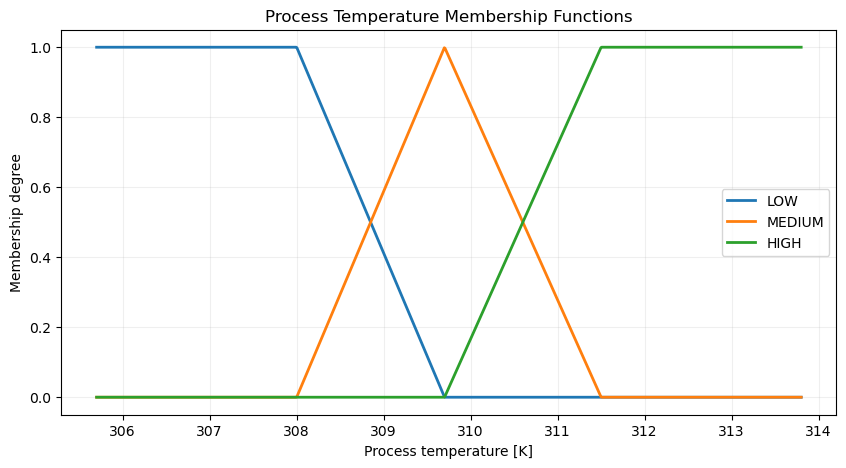

In [10]:
# Visualize Process Temperature Membership Functions

plt.figure(figsize=(10, 5))

plt.plot(process_temp, process_low, label="LOW", linewidth=2)
plt.plot(process_temp, process_medium, label="MEDIUM", linewidth=2)
plt.plot(process_temp, process_high, label="HIGH", linewidth=2)

plt.title("Process Temperature Membership Functions")
plt.xlabel("Process temperature [K]")
plt.ylabel("Membership degree")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [11]:
# Verify Process Temperature fuzzy partition

process_membership_sum = (
    process_low +
    process_medium +
    process_high
)

print("Minimum sum of memberships:", process_membership_sum.min())
print("Maximum sum of memberships:", process_membership_sum.max())

print(
    "All points approximately equal to 1:",
    np.allclose(process_membership_sum, 1.0, atol=1e-6)
)

print(
    "Maximum deviation from 1:",
    np.max(np.abs(process_membership_sum - 1.0))
)

Minimum sum of memberships: 1.0
Maximum sum of memberships: 1.0
All points approximately equal to 1: True
Maximum deviation from 1: 0.0


### Phase 2.3.6 — Phân tích chi tiết mật độ dữ liệu Rotational Speed theo các vùng vận hành

In [12]:
# Phase 2.3.6 — Detailed analysis of Rotational Speed

rpm_series = train_df["Rotational speed [rpm]"]

rpm_bins = [
    1168,
    1300,
    1400,
    1500,
    1600,
    1700,
    1800,
    2000,
    2200,
    2500,
    3000
]

rpm_distribution = pd.cut(
    rpm_series,
    bins=rpm_bins,
    include_lowest=True,
    right=False
).value_counts().sort_index()

rpm_percentage = (
    rpm_distribution / len(rpm_series) * 100
).round(2)

rpm_analysis = pd.DataFrame({
    "Count": rpm_distribution,
    "Percentage (%)": rpm_percentage
})

display(rpm_analysis)

,Count,Percentage (%)
Rotational speed [rpm],,
"[1168, 1300)",126,2.10
"[1300, 1400)",978,16.30
"[1400, 1500)",1827,30.45
"[1500, 1600)",1422,23.70
"[1600, 1700)",842,14.03
"[1700, 1800)",355,5.92
"[1800, 2000)",310,5.17
"[2000, 2200)",78,1.30
"[2200, 2500)",38,0.63


### Phase 2.3.7 — Xây dựng, Trực quan hóa và Kiểm tra Membership Functions cho Rotational Speed (Bất đối xứng / Lệch phải)

In [13]:
# Phase 2.3.7 — Rotational Speed Membership Functions

rpm = universes["rpm"]

rpm_low = fuzz.trapmf(
    rpm,
    [1168, 1168, 1350, 1500]
)

rpm_medium = fuzz.trimf(
    rpm,
    [1400, 1504, 1750]
)

rpm_high = fuzz.trapmf(
    rpm,
    [1600, 1880, 2886, 2886]
)

print("Rotational Speed MFs created.")
print("LOW    :", rpm_low.shape)
print("MEDIUM :", rpm_medium.shape)
print("HIGH   :", rpm_high.shape)

Rotational Speed MFs created.
LOW    : (1000,)
MEDIUM : (1000,)
HIGH   : (1000,)


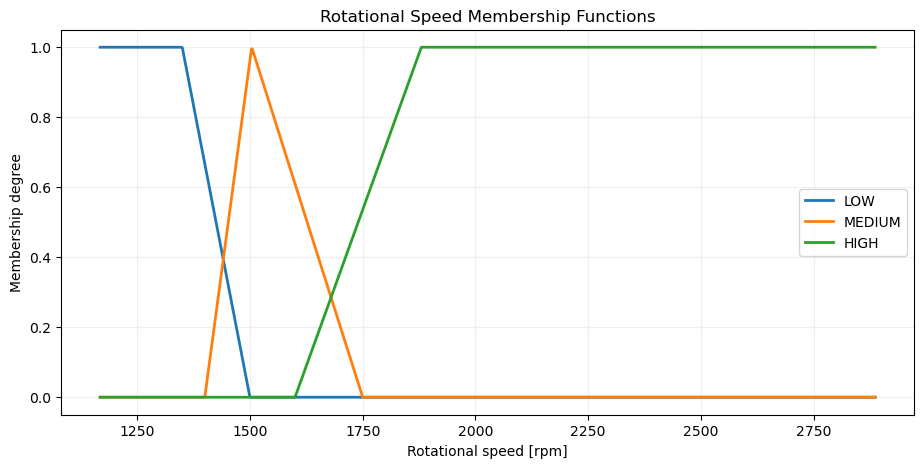

In [14]:
# Visualize Rotational Speed Membership Functions

plt.figure(figsize=(11, 5))

plt.plot(rpm, rpm_low, label="LOW", linewidth=2)
plt.plot(rpm, rpm_medium, label="MEDIUM", linewidth=2)
plt.plot(rpm, rpm_high, label="HIGH", linewidth=2)

plt.title("Rotational Speed Membership Functions")
plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Membership degree")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [15]:
# Verify Rotational Speed fuzzy partition

rpm_membership_sum = (
    rpm_low +
    rpm_medium +
    rpm_high
)

print("Minimum sum of memberships:", rpm_membership_sum.min())
print("Maximum sum of memberships:", rpm_membership_sum.max())

print(
    "All points approximately equal to 1:",
    np.allclose(rpm_membership_sum, 1.0, atol=1e-6)
)

print(
    "Maximum deviation from 1:",
    np.max(np.abs(rpm_membership_sum - 1.0))
)

Minimum sum of memberships: 0.5360769596541953
Maximum sum of memberships: 1.0
All points approximately equal to 1: False
Maximum deviation from 1: 0.46392304034580467


### Phase 2.3.7 (Revision) — Tinh chỉnh tập mờ MEDIUM của Rotational Speed để tối ưu Overlap

In [16]:
# Revise the MEDIUM membership function for Rotational Speed

rpm_medium = fuzz.trimf(
    rpm,
    [1350, 1504, 1800]
)

rpm_membership_sum = (
    rpm_low +
    rpm_medium +
    rpm_high
)

print("Minimum sum of memberships:", rpm_membership_sum.min())
print("Maximum sum of memberships:", rpm_membership_sum.max())

print(
    "All points approximately equal to 1:",
    np.allclose(rpm_membership_sum, 1.0, atol=1e-6)
)

print(
    "Maximum deviation from 1:",
    np.max(np.abs(rpm_membership_sum - 1.0))
)

Minimum sum of memberships: 0.6759400326967895
Maximum sum of memberships: 1.0
All points approximately equal to 1: False
Maximum deviation from 1: 0.3240599673032105


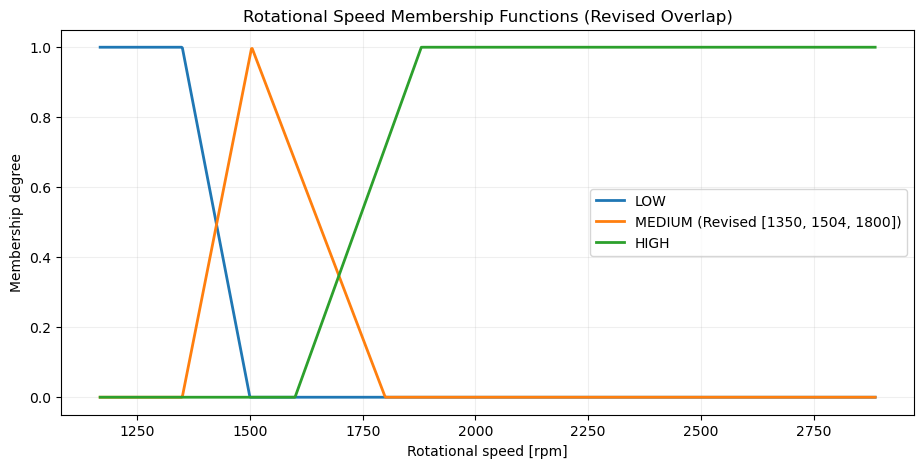

In [17]:
# Re-visualize Rotational Speed Membership Functions (Revised)

plt.figure(figsize=(11, 5))

plt.plot(rpm, rpm_low, label="LOW", linewidth=2)
plt.plot(rpm, rpm_medium, label="MEDIUM (Revised [1350, 1504, 1800])", linewidth=2)
plt.plot(rpm, rpm_high, label="HIGH", linewidth=2)

plt.title("Rotational Speed Membership Functions (Revised Overlap)")
plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Membership degree")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

---
### Phase 2.3.8 — Phân tích chi tiết mật độ dữ liệu Torque [Nm] theo các vùng

In [18]:
# Phase 2.3.8 — Detailed analysis of Torque distribution

torque = train_df["Torque [Nm]"]

torque_bins = np.arange(0, 81, 5)
torque_counts, torque_edges = np.histogram(torque, bins=torque_bins)

torque_distribution = pd.DataFrame({
    "Range [Nm]": [
        f"{torque_edges[i]:.0f}–{torque_edges[i+1]:.0f}"
        for i in range(len(torque_edges) - 1)
    ],
    "Count": torque_counts,
    "Percentage (%)": torque_counts / len(torque) * 100
})

display(torque_distribution)

print("Skewness:", torque.skew())
print("Kurtosis:", torque.kurt())

,Range [Nm],Count,Percentage (%)
0,0–5,3,0.050000
1,5–10,7,0.116667
2,10–15,28,0.466667
3,15–20,101,1.683333
4,20–25,287,4.783333
5,25–30,504,8.400000
6,30–35,901,15.016667
7,35–40,1146,19.100000
8,40–45,1144,19.066667
9,45–50,938,15.633333


Skewness: -0.034398208742438735
Kurtosis: 0.03800196258151756


### Phase 2.3.9 — Xây dựng và Kiểm tra Membership Functions cho Torque [Nm]

In [19]:
# Phase 2.3.9 — Torque Membership Functions

torque = universes["torque"]

torque_low = fuzz.trapmf(
    torque,
    [3.8, 3.8, 25.0, 40.0]
)

torque_medium = fuzz.trimf(
    torque,
    [25.0, 40.0, 55.0]
)

torque_high = fuzz.trapmf(
    torque,
    [40.0, 55.0, 76.2, 76.2]
)

print("Torque MFs created.")
print("LOW    :", torque_low.shape)
print("MEDIUM :", torque_medium.shape)
print("HIGH   :", torque_high.shape)

Torque MFs created.
LOW    : (1000,)
MEDIUM : (1000,)
HIGH   : (1000,)


In [20]:
# Verify Torque fuzzy partition

torque_membership_sum = (
    torque_low +
    torque_medium +
    torque_high
)

print("Minimum sum of memberships:", torque_membership_sum.min())
print("Maximum sum of memberships:", torque_membership_sum.max())
print(
    "Maximum deviation from 1:",
    np.abs(torque_membership_sum - 1).max()
)

torque_check = pd.DataFrame({
    "Torque": torque,
    "LOW": torque_low,
    "MEDIUM": torque_medium,
    "HIGH": torque_high,
    "SUM": torque_membership_sum
})

display(
    torque_check.iloc[
        np.linspace(0, len(torque_check)-1, 15).astype(int)
    ]
)

Minimum sum of memberships: 1.0
Maximum sum of memberships: 1.0
Maximum deviation from 1: 0.0


,Torque,LOW,MEDIUM,HIGH,SUM
0,3.800000,1.000000,0.000000,0.000000,1.0
71,8.945546,1.000000,0.000000,0.000000,1.0
142,14.091091,1.000000,0.000000,0.000000,1.0
214,19.309109,1.000000,0.000000,0.000000,1.0
285,24.454655,1.000000,0.000000,0.000000,1.0
356,29.600200,0.693320,0.306680,0.000000,1.0
428,34.818218,0.345452,0.654548,0.000000,1.0
499,39.963764,0.002416,0.997584,0.000000,1.0
570,45.109309,0.000000,0.659379,0.340621,1.0
642,50.327327,0.000000,0.311512,0.688488,1.0


---
### Phase 2.3.10 — Phân tích chi tiết mật độ dữ liệu Tool Wear [min] theo các vùng

In [21]:
# Phase 2.3.10 — Detailed analysis of Tool Wear distribution

tool_wear = train_df["Tool wear [min]"]

tool_wear_bins = np.arange(0, 261, 20)

tool_wear_counts, tool_wear_edges = np.histogram(
    tool_wear,
    bins=tool_wear_bins
)

tool_wear_distribution = pd.DataFrame({
    "Range [min]": [
        f"{tool_wear_edges[i]:.0f}–{tool_wear_edges[i+1]:.0f}"
        for i in range(len(tool_wear_edges) - 1)
    ],
    "Count": tool_wear_counts,
    "Percentage (%)": tool_wear_counts / len(tool_wear) * 100
})

display(tool_wear_distribution)

print("Skewness:", tool_wear.skew())
print("Kurtosis:", tool_wear.kurt())

,Range [min],Count,Percentage (%)
0,0–20,569,9.483333
1,20–40,548,9.133333
2,40–60,543,9.050000
3,60–80,542,9.033333
4,80–100,534,8.900000
5,100–120,554,9.233333
6,120–140,550,9.166667
7,140–160,547,9.116667
8,160–180,546,9.100000
9,180–200,549,9.150000


Skewness: 0.023025675348873353
Kurtosis: -1.1584955333868814


### Phase 2.3.11 — Xây dựng và Kiểm tra Membership Functions cho Tool Wear [min]

In [22]:
# Phase 2.3.11 — Tool Wear Membership Functions

tool_wear = universes["tool_wear"]

tool_wear_low = fuzz.trapmf(
    tool_wear,
    [0, 0, 54, 109]
)

tool_wear_medium = fuzz.trimf(
    tool_wear,
    [54, 109, 164]
)

tool_wear_high = fuzz.trapmf(
    tool_wear,
    [109, 164, 253, 253]
)

print("Tool Wear MFs created.")
print("LOW    :", tool_wear_low.shape)
print("MEDIUM :", tool_wear_medium.shape)
print("HIGH   :", tool_wear_high.shape)

Tool Wear MFs created.
LOW    : (1000,)
MEDIUM : (1000,)
HIGH   : (1000,)


In [23]:
# Verify Tool Wear fuzzy partition

tool_wear_membership_sum = (
    tool_wear_low +
    tool_wear_medium +
    tool_wear_high
)

print(
    "Minimum sum of memberships:",
    tool_wear_membership_sum.min()
)

print(
    "Maximum sum of memberships:",
    tool_wear_membership_sum.max()
)

print(
    "Maximum deviation from 1:",
    np.abs(tool_wear_membership_sum - 1).max()
)

tool_wear_check = pd.DataFrame({
    "Tool Wear": tool_wear,
    "LOW": tool_wear_low,
    "MEDIUM": tool_wear_medium,
    "HIGH": tool_wear_high,
    "SUM": tool_wear_membership_sum
})

display(
    tool_wear_check.iloc[
        np.linspace(0, len(tool_wear_check) - 1, 15).astype(int)
    ]
)

Minimum sum of memberships: 1.0
Maximum sum of memberships: 1.0
Maximum deviation from 1: 0.0


,Tool Wear,LOW,MEDIUM,HIGH,SUM
0,0.000000,1.000000,0.000000,0.000000,1.0
71,17.980981,1.000000,0.000000,0.000000,1.0
142,35.961962,1.000000,0.000000,0.000000,1.0
214,54.196196,0.996433,0.003567,0.000000,1.0
285,72.177177,0.669506,0.330494,0.000000,1.0
356,90.158158,0.342579,0.657421,0.000000,1.0
428,108.392392,0.011047,0.988953,0.000000,1.0
499,126.373373,0.000000,0.684120,0.315880,1.0
570,144.354354,0.000000,0.357194,0.642806,1.0
642,162.588589,0.000000,0.025662,0.974338,1.0


---
### Phase 2.3.12 — Trực quan hóa tổng hợp Membership Functions của 5 biến cảm biến (Checkpoint)

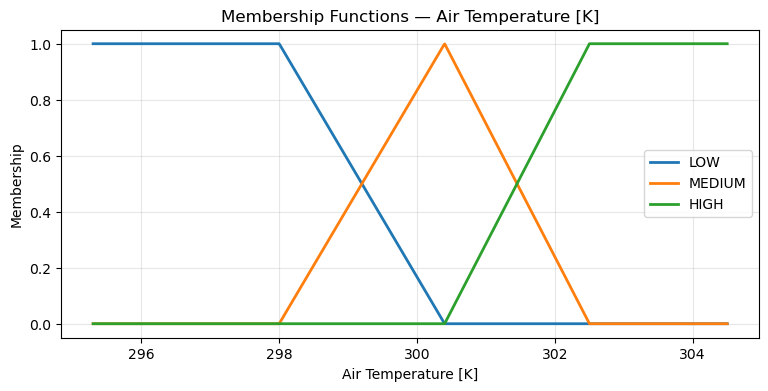

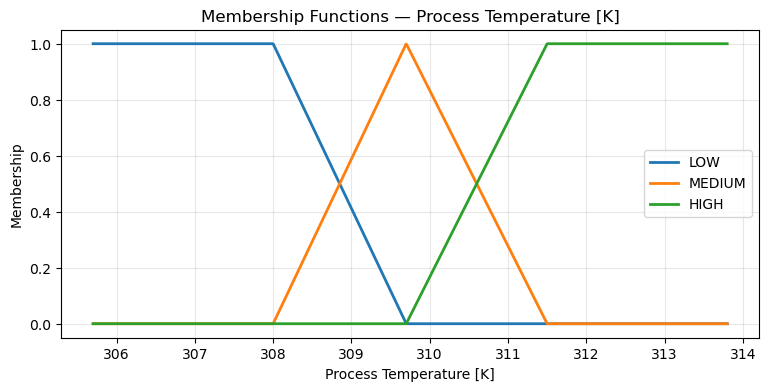

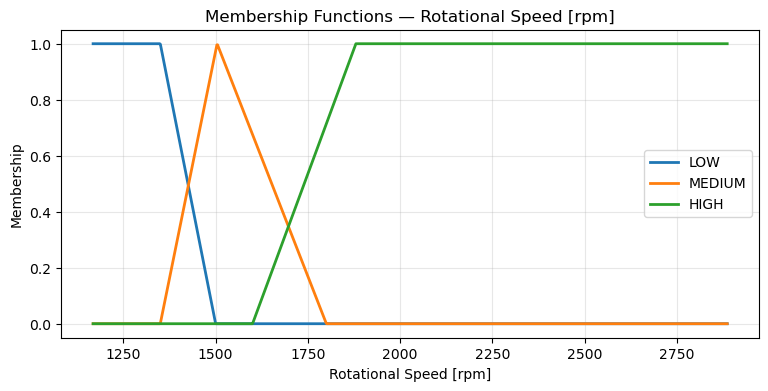

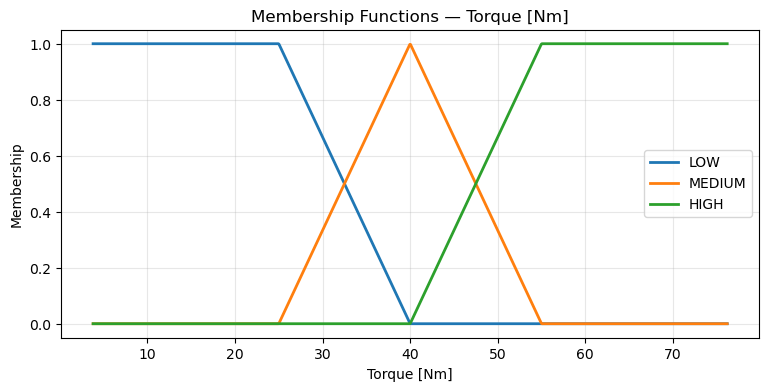

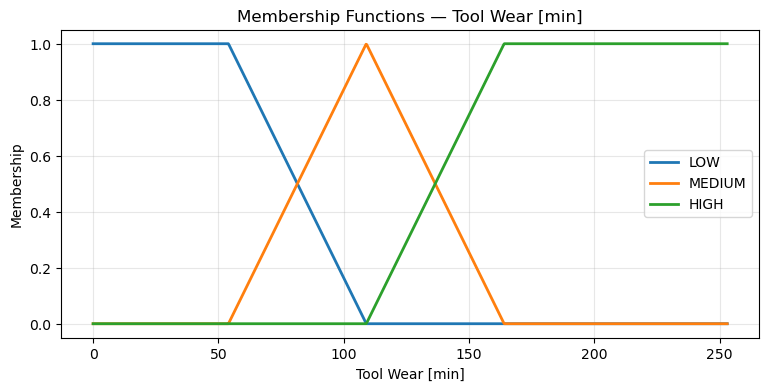

In [24]:
# Phase 2.3.12 — Visualization checkpoint: all 5 input MFs

import matplotlib.pyplot as plt

mf_configs = [
    (
        "Air Temperature [K]",
        universes["air_temp"],
        air_low,
        air_medium,
        air_high
    ),
    (
        "Process Temperature [K]",
        universes["process_temp"],
        process_low,
        process_medium,
        process_high
    ),
    (
        "Rotational Speed [rpm]",
        universes["rpm"],
        rpm_low,
        rpm_medium,
        rpm_high
    ),
    (
        "Torque [Nm]",
        universes["torque"],
        torque_low,
        torque_medium,
        torque_high
    ),
    (
        "Tool Wear [min]",
        universes["tool_wear"],
        tool_wear_low,
        tool_wear_medium,
        tool_wear_high
    ),
]

for title, universe, low, medium, high in mf_configs:
    plt.figure(figsize=(9, 4))

    plt.plot(universe, low, label="LOW", linewidth=2)
    plt.plot(universe, medium, label="MEDIUM", linewidth=2)
    plt.plot(universe, high, label="HIGH", linewidth=2)

    plt.title(f"Membership Functions — {title}")
    plt.xlabel(title)
    plt.ylabel("Membership")
    plt.ylim(-0.05, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()